# 04 · User Behavior Modeling — 用户行为预测建模（转化 & 流失）

## 1. 模块目标（Objective）

本模块基于现有两张表：

- 用户级特征+分群表（`user_features_with_segments.parquet`）
- 行为日志表（`events_enriched_cat.parquet`）

构建用户级预测模型，用于识别：

- **高转化潜力用户**（未来 N 天可能发生 purchase / transaction 事件）
- **高流失风险用户**（未来一段时间可能不再回流/活跃）

核心目标包括：

- 用严格的 **观察窗 / 预测窗** 构建训练数据，避免信息泄漏
- 训练并对比多模型（LR / LightGBM / XGBoost）
- 通过 AUC、PR-AUC、Lift 等指标验证业务可用性
- 输出可行动的用户名单（高潜转化 / 高风险流失）

---

## 2. 数据输入（Input Tables）

本模块**仅使用两张表**：

- **events_enriched_cat.parquet**  
  用户行为日志（至少包含 `user_id`, `event_time`, `event_type`，以及类目相关字段如 `category_id/top_category` 等）

- **user_features_with_segments.parquet**  
  用户级特征宽表（LRFM-C + 分群结果），每行一个用户，包含画像特征与分群标签（如 `cluster_kmeans` / `cluster_dbscan` 等）

> 注：本模块不依赖订单表；转化与流失均从 `events` 事件口径定义。

---

## 3. 关键设计决策（Key Design Choices）

### 3.1 预测任务定义（Task Definition）

#### 转化预测（Conversion via Events）

以行为日志中的“转化事件”作为标签来源（你可以按数据实际的事件名选择其一）：

- 典型转化事件：`purchase` / `transaction` / `order`（以数据中存在者为准）
- `label_conversion = 1`：用户在预测窗内出现过“转化事件”
- `label_conversion = 0`：预测窗内未出现转化事件

> 该定义适用于“下单/成交事件已记录在 events 中”的数据结构。

#### 流失预测（Churn / Inactivity）

基于用户回流周期的分位数来定义“流失阈值”：

- 对历史用户计算相邻两次活跃间隔 `gap_days`
- 选择分位数阈值 `T_churn`（如 P80/P90/P95）
- `label_churn = 1`：anchor 时点距最近一次活跃 > `T_churn`
- `label_churn = 0`：否则

> “活跃”口径默认为任意事件（view/addtocart/purchase 都算），也可改为“关键事件活跃”。

---

### 3.2 时间窗设计（Windowing Strategy）

为避免信息泄漏，严格划分：

- **观察窗（Lookback Window）**：anchor_date 往前 L 天（只用来做特征）
- **预测窗（Prediction Window）**：anchor_date 往后 N 天（只用来生成 label）

典型配置示例：

- `L = 60/90 days`
- `N = 7/14/30 days`
- anchor_date 以周频滚动生成（扩大样本量并增强泛化）

---

### 3.3 特征构成（Feature Composition）

特征由两部分组成（全部可由两张表得到）：

1) **用户画像 + 分群（来自 user_features_with_segments）**
- LRFM-C 画像：`recency_days`, `frequency`, `monetary_proxy`, `n_categories`, `top_category_share` 等
- 分群标签：`cluster_kmeans`（主），`cluster_dbscan/is_noise`（可选）

2) **近端行为特征（来自 events_enriched_cat 的观察窗聚合）**
- 近 7/14/30 天：`view_cnt`, `addtocart_cnt`, `purchase_cnt`, `events_total`
- `active_days`, `behavior_density`（行为强度/密度）
- 意图比率：`addtocart_rate`, `purchase_rate`
- 类目偏好动态：近端 `n_categories_30d`, `top_category_share_30d`（如可做）

---

## 4. 数据集构建与切分（Dataset Build & Split）

### 4.1 样本构建（Training Sample Construction）

以滚动 anchor_date 方式生成“用户-时间点”样本：

- 对每个 anchor_date：
  - 从观察窗聚合 events 得到近端特征
  - 读取 user_features_with_segments 的静态画像与分群特征
  - 从预测窗 events 生成 label（转化 / 流失）
  - 合并为一张训练样本表

最终得到两份训练集：

- `train_table_conversion`：转化预测训练集
- `train_table_churn`：流失预测训练集

---

### 4.2 验证策略（Temporal Validation）

采用时间切分验证（Temporal Split）：

- Train：较早的 anchor_date
- Valid：中间的 anchor_date
- Test：最新的 anchor_date

避免随机切分造成“未来信息泄漏”和虚高评估。

---

## 5. 模型训练与对比（Model Training & Benchmark）

### 5.1 模型选择（Models）

对比三类模型：

- **Logistic Regression（Baseline）**
  - 作为可解释基线，评估特征工程是否有效
- **LightGBM（Main Model）**
  - 对非线性与特征交互更敏感，通常效果更好
- **XGBoost（Alternative）**
  - 与 LightGBM 对照验证稳定性与上限

---

### 5.2 类不平衡处理（Imbalance Handling）

转化/流失任务通常正样本较少：

- `class_weight = balanced`（LR / Tree 通用）
- 采样对比（可选）：SMOTE / RandomOverSampler（仅在训练集上做）

---

## 6. 模型评估指标（Evaluation Metrics）

从“排序能力 + 业务可用性”两层评估：

### 6.1 排序指标（Ranking）

- **AUC-ROC**
- **PR-AUC**（对类不平衡更敏感，尤其适合转化）

### 6.2 业务指标（Business-Oriented）

- **Lift / Decile Chart**
  - Top 10% 用户的真实转化率 / 全体转化率
- **Recall@K**
  - Top K% 覆盖真实正样本比例（运营触达最关心）

### 6.3 概率可信度（Calibration）

- Calibration Curve（可选）
- Brier Score（可选）

用于支持“按概率分层投放/触达强度”的决策。

---

## 7. 可解释性与策略落地（Interpretability & Actions）

### 7.1 SHAP 解释（SHAP Explainability）

对 LightGBM / XGBoost 输出：

- 全局特征重要性 TopN
- 关键特征对预测的影响方向（正/负）

将“模型结论”转换成可讲清楚的运营洞察。

---

### 7.2 用户名单输出（Scoring & Export）

基于预测概率导出两类名单（含分群标签，便于分层运营）：

- **高转化潜力用户**
  - `p_conversion` Top 5% / Top 10%（或阈值如 0.8）
- **高流失风险用户**
  - `p_churn` Top 5% / Top 10%（或阈值如 0.8）

并按“分群 × 概率”给出运营优先级（示例）：

- 高价值群 + 高流失：优先唤回（强激励）
- 潜力群 + 高转化：加购催付/推荐/优惠
- 浏览型 + 低转化：内容/页面引导，低成本触达
- 低活跃 + 高流失：低成本召回或减少投入

---

## 8. 模块输出（Outputs）

本模块最终产出：

- **转化预测训练集**：`train_table_conversion.parquet`
- **流失预测训练集**：`train_table_churn.parquet`
- **模型对比结果表**（LR / LGBM / XGB：AUC、PR-AUC、Recall@10%、Lift@10%）
- **Lift / Decile 图表**（转化 & 流失各一套）
- **SHAP 输出**（Top 特征 + 可视化）
- **用户名单导出**
  - `high_potential_users.csv`
  - `high_risk_users.csv`

---

## 9. 后续分析方向（Next Steps）

基于本模块结果可进一步扩展：

1. 分群 × 转化概率/流失概率对比（确定人群策略优先级）
2. 以名单触达为核心设计 A/B 测试验证增量收益
3. Optuna / 贝叶斯优化系统调参，提高上限
4. 引入更强的时间特征（趋势、周期、最近变化率）提升近端预测能力
5. 建立“预测 → 触达 → 反馈 → 再训练”的闭环迭代机制
`

---

## 9. 后续分析方向（Next Steps）

基于本模块预测结果，可进一步开展：

1. 分群 × 转化概率 / 流失概率对比分析（策略优先级排序）
2. 将模型输出用于 A/B 测试验证运营动作的真实提升
3. 引入 Optuna / 贝叶斯优化进行更系统的超参搜索
4. 加入时间序列特征或序列模型（如 TCN / Transformer）探索上限
5. 建立长期 LTV 预测与预算分配框架，实现“预测 → 投放 → 反馈闭环”


In [1]:
import pandas as pd
import numpy as np

EVENTS_PATH = r"E:\data_analysis\ecommece\data_clean\01_feature_engineering\events_enriched_cat.parquet"
USERS_PATH  = r"E:\data_analysis\ecommece\data_clean\02_segmentation_kmeans_dbscan\user_features_with_segments.parquet"

events = pd.read_parquet(EVENTS_PATH)   # 需要 pyarrow
users  = pd.read_parquet(USERS_PATH)

print("events shape:", events.shape)
print("users  shape:", users.shape)
print("\nEvents columns (head 30):", list(events.columns)[:30])
print("Users  columns (head 30):", list(users.columns)[:30])

events shape: (2500065, 8)
users  shape: (187481, 21)

Events columns (head 30): ['visitorid', 'itemid', 'event', 'timestamp', 'dt', 'transactionid', 'available', 'categoryid']
Users  columns (head 30): ['visitorid', 'recency_days', 'view', 'addtocart', 'transaction', 'transaction_cnt', 'n_categories', 'top_category_share', 'active_days', 'lifetime_days', 'events_total', 'behavior_density', 'addtocart_rate', 'purchase_rate', 'active_days_30d', 'txn_30d', 'cluster_k4', 'cluster_name', 'cluster_hdb', 'cluster_k4_name', 'is_hdb_noise']


In [2]:
events.head(10)

,visitorid,itemid,event,timestamp,dt,transactionid,available,categoryid
0,257597,355908,view,1433221332117,2015-06-02 05:02:12.117000+00:00,<NA>,1,1173
1,992329,248676,view,1433224214164,2015-06-02 05:50:14.164000+00:00,<NA>,1,1231
2,483717,253185,view,1433221955914,2015-06-02 05:12:35.914000+00:00,<NA>,0,914
3,951259,367447,view,1433221337106,2015-06-02 05:02:17.106000+00:00,<NA>,0,491
4,972639,22556,view,1433224086234,2015-06-02 05:48:06.234000+00:00,<NA>,0,1074
5,810725,443030,view,1433221923240,2015-06-02 05:12:03.240000+00:00,<NA>,1,1098
6,794181,439202,view,1433223291897,2015-06-02 05:34:51.897000+00:00,<NA>,1,1542
7,824915,428805,view,1433220899221,2015-06-02 04:54:59.221000+00:00,<NA>,0,646
8,339335,82389,view,1433221204592,2015-06-02 05:00:04.592000+00:00,<NA>,0,1404
9,176446,10572,view,1433222162373,2015-06-02 05:16:02.373000+00:00,<NA>,1,1037


In [3]:
users.head(10)

,visitorid,recency_days,view,addtocart,transaction,transaction_cnt,n_categories,top_category_share,active_days,lifetime_days,...,behavior_density,addtocart_rate,purchase_rate,active_days_30d,txn_30d,cluster_k4,cluster_name,cluster_hdb,cluster_k4_name,is_hdb_noise
0,0,6,3,0,0,0,3,0.333333,1,0,...,3.000000,0.0,0.0,1.0,0.0,3,"Recent Returnees (Active in 30d, No Purchase)",-1,"Recent Returnees (Active in 30d, No Purchase)",True
1,2,41,8,0,0,0,2,0.750000,1,0,...,8.000000,0.0,0.0,0.0,0.0,1,Dormant / Churn Risk,9,Dormant / Churn Risk,False
2,6,17,5,1,0,0,1,1.000000,2,0,...,3.000000,0.2,0.0,2.0,0.0,3,"Recent Returnees (Active in 30d, No Purchase)",-1,"Recent Returnees (Active in 30d, No Purchase)",True
3,7,124,3,0,0,0,2,0.666667,2,1,...,1.500000,0.0,0.0,0.0,0.0,1,Dormant / Churn Risk,10,Dormant / Churn Risk,False
4,23,98,3,0,0,0,2,0.666667,2,4,...,1.500000,0.0,0.0,0.0,0.0,1,Dormant / Churn Risk,10,Dormant / Churn Risk,False
5,37,35,8,0,0,0,2,0.875000,4,5,...,2.000000,0.0,0.0,0.0,0.0,0,Active Browsers (Low Conversion),-1,Active Browsers (Low Conversion),True
6,51,12,6,0,0,0,2,0.833333,1,0,...,6.000000,0.0,0.0,1.0,0.0,3,"Recent Returnees (Active in 30d, No Purchase)",5,"Recent Returnees (Active in 30d, No Purchase)",False
7,54,0,11,0,0,0,2,0.909091,3,2,...,3.666667,0.0,0.0,3.0,0.0,3,"Recent Returnees (Active in 30d, No Purchase)",-1,"Recent Returnees (Active in 30d, No Purchase)",True
8,60,89,3,0,0,0,1,1.000000,1,0,...,3.000000,0.0,0.0,0.0,0.0,1,Dormant / Churn Risk,8,Dormant / Churn Risk,False
9,64,86,7,0,0,0,3,0.571429,2,8,...,3.500000,0.0,0.0,0.0,0.0,0,Active Browsers (Low Conversion),10,Active Browsers (Low Conversion),False


In [4]:
events = events.rename(columns = {"visitorid": "user_id", "event": "event_type"})
users = users.rename(columns = {"visitorid": "user_id"})

In [5]:
if "dt" in events.columns:
    events["event_time"] = pd.to_datetime(events["dt"], errors="coerce")

bad_dt_ratio = events["event_time"].isna().mean()
print("dt parse NaN ratio:", bad_dt_ratio)

if bad_dt_ratio > 0.2 and "timestamp" in events.columns:
    events["event_time"] = pd.to_datetime(events["timestamp"], unit="ms", errors="coerce")

events = events.dropna(subset=["user_id", "event_time", "event_type"])
events["event_type"] = events["event_type"].astype(str)

dt parse NaN ratio: 0.0


In [6]:
events = events.dropna(subset=["user_id", "event_time", "event_type"])
events["event_type"] = events["event_type"].astype(str)

In [7]:
if users["user_id"].duplicated().any():
    users = users.drop_duplicates("user_id")

In [8]:
drop_cols = []
if "cluster_name" in users.columns and "cluster_k4_name" in users.columns:
    same_ratio = (users["cluster_name"].fillna("") == users["cluster_k4_name"].fillna("")).mean()
    print("cluster_name == cluster_k4_name ratio:", same_ratio)
    if same_ratio > 0.95:
        drop_cols.append("cluster_name")

cluster_name == cluster_k4_name ratio: 0.9446877283564734


In [9]:
if drop_cols:
    users = users.drop(columns=drop_cols)

print("events shape:", events.shape)
print("users  shape:", users.shape)
print("users columns:", users.columns.tolist())

print("\nEvent time range:", events["event_time"].min(), "->", events["event_time"].max())
print("event_type value counts:\n", events["event_type"].value_counts().head(10))

events shape: (2500065, 9)
users  shape: (187481, 21)
users columns: ['user_id', 'recency_days', 'view', 'addtocart', 'transaction', 'transaction_cnt', 'n_categories', 'top_category_share', 'active_days', 'lifetime_days', 'events_total', 'behavior_density', 'addtocart_rate', 'purchase_rate', 'active_days_30d', 'txn_30d', 'cluster_k4', 'cluster_name', 'cluster_hdb', 'cluster_k4_name', 'is_hdb_noise']

Event time range: 2015-05-03 03:00:04.384000+00:00 -> 2015-09-18 02:59:47.788000+00:00
event_type value counts:
 event_type
view           2409950
addtocart        68133
transaction      21982
Name: count, dtype: int64


In [10]:
diff = users[["user_id","cluster_name","cluster_k4_name"]].copy()
diff["same"] = diff["cluster_name"].fillna("") == diff["cluster_k4_name"].fillna("")
print("Mismatch count:", (~diff["same"]).sum())
diff.loc[~diff["same"]].head(1000)

Mismatch count: 10370


,user_id,cluster_name,cluster_k4_name,same
24,172,Core Buyers (High Value),Core Buyers,False
26,186,Core Buyers (High Value),Core Buyers,False
30,264,Core Buyers (High Value),Core Buyers,False
54,419,Core Buyers (High Value),Core Buyers,False
55,420,Core Buyers (High Value),Core Buyers,False
...,...,...,...,...
17915,134805,Core Buyers (High Value),Core Buyers,False
17923,134868,Core Buyers (High Value),Core Buyers,False
17964,135153,Core Buyers (High Value),Core Buyers,False
17967,135201,Core Buyers (High Value),Core Buyers,False


In [11]:
if "cluster_name" in users.columns:
    users = users.drop(columns=["cluster_name"])

print([c for c in users.columns if "cluster" in c.lower()])

['cluster_k4', 'cluster_hdb', 'cluster_k4_name']


In [ ]:
user.drop("")

In [18]:
users[["transaction"]].describe()

,transaction
count,187481.000000
mean,0.113724
std,2.195732
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,543.000000


In [19]:
CONVERSION_EVENT = "transaction"

LOOKBACK_DAYS = 60   # 观察窗：往前60天做特征
HORIZON_DAYS  = 14   # 预测窗：往后14天打转化标签
ANCHOR_FREQ   = "W-MON"  # 每周一一个anchor（样本更多）

In [23]:
e = events[["user_id", "event_time"]].sort_values(["user_id", "event_time"]).copy()
e["prev_time"] = e.groupby("user_id")["event_time"].shift(1)
e["gap_days"] = (e["event_time"] - e["prev_time"]).dt.total_seconds() / 86400.0

gaps = e["gap_days"].dropna()

gaps = gaps[(gpas > 0) & (gaps < 180)]

T_CHURN = float(gaps.quantile(0.90)) if len(gaps) else 30.0
T_CHURN = max(7.0, min(T_CHURN, 120.0))
print("T_CHURN (P90 days):", T_CHURN)

T_CHURN (P90 days): 7.0


In [25]:
min_t = events["event_time"].min()
max_t = events["event_time"].max()

start = min_t + pd.Timedelta(days = LOOKBACK_DAYS)
end   = max_t - pd.Timedelta(days=HORIZON_DAYS)

anchors = pd.date_range(start=start, end=end, freq=ANCHOR_FREQ)

print("Event time range:", min_t, "->", max_t)
print("Anchors:", len(anchors), "| first:", anchors[0], "| last:", anchors[-1])

Event time range: 2015-05-03 03:00:04.384000+00:00 -> 2015-09-18 02:59:47.788000+00:00
Anchors: 9 | first: 2015-07-06 03:00:04.384000+00:00 | last: 2015-08-31 03:00:04.384000+00:00


In [26]:
print("\nEvent counts:", events["event_type"].value_counts())


Event counts: event_type
view           2409950
addtocart        68133
transaction      21982
Name: count, dtype: int64


In [27]:
EPS = 1e-9

events2 = events[["user_id", "event_time", "event_type"]].copy()
events2["event_type"] = events2["event_type"].astype(str)
events2["event_date"] = events2["event_time"].dt.date

In [28]:
events2 = events2.sort_values(["user_id", "event_time"])

In [29]:
def build_features_for_anchor(anchor_date, lookback_days=LOOKBACK_DAYS):
    """观察窗特征：只用 [anchor-lookback, anchor)"""
    start = pd.Timestamp(anchor_date) - pd.Timedelta(days=lookback_days)
    end   = pd.Timestamp(anchor_date)

    w = events2[(events2["event_time"] >= start) & (events2["event_time"] < end)].copy()
    if w.empty:
        # 返回空表，后面 merge 会补0
        return pd.DataFrame(columns=[
            "user_id", "events_total", "active_days", "days_since_last_event",
            "view_cnt", "addtocart_cnt", "transaction_cnt_w",
            "addtocart_rate_w", "purchase_rate_w", "behavior_density_w"
        ])

    # 基础聚合
    base = (w.groupby("user_id")
              .agg(events_total=("event_type", "size"),
                   active_days=("event_date", "nunique"),
                   last_event_time=("event_time", "max"))
              .reset_index())
    base["days_since_last_event"] = (end - base["last_event_time"]).dt.days

    # 三类事件计数：view/addtocart/transaction
    pivot = (w.pivot_table(index="user_id", columns="event_type", values="event_time",
                           aggfunc="count", fill_value=0)
              .reset_index())

    for col in ["view", "addtocart", "transaction"]:
        if col not in pivot.columns:
            pivot[col] = 0

    pivot = pivot.rename(columns={
        "view": "view_cnt",
        "addtocart": "addtocart_cnt",
        "transaction": "transaction_cnt_w"
    })

    feat = base.merge(pivot[["user_id","view_cnt","addtocart_cnt","transaction_cnt_w"]],
                      on="user_id", how="left")

    # 比率/密度（用观察窗内统计）
    feat["addtocart_rate_w"] = feat["addtocart_cnt"] / (feat["view_cnt"] + EPS)
    feat["purchase_rate_w"]  = feat["transaction_cnt_w"] / (feat["addtocart_cnt"] + EPS)
    feat["behavior_density_w"] = feat["events_total"] / (feat["active_days"] + EPS)

    feat = feat.drop(columns=["last_event_time"], errors="ignore")
    return feat

def build_label_conversion(anchor_date, horizon_days=HORIZON_DAYS):
    """预测窗标签：未来N天是否 transaction"""
    start = pd.Timestamp(anchor_date)
    end   = start + pd.Timedelta(days=horizon_days)

    f = events2[(events2["event_time"] >= start) & (events2["event_time"] < end)].copy()
    if f.empty:
        return pd.DataFrame({"user_id": [], "label_conversion": []})

    y = (f[f["event_type"] == CONVERSION_EVENT]
         .groupby("user_id").size().gt(0).astype(int)
         .rename("label_conversion").reset_index())
    return y

def build_label_churn(anchor_date, churn_threshold_days=T_CHURN):
    """anchor时点：距最近一次事件是否 > T_CHURN"""
    end = pd.Timestamp(anchor_date)

    # 取 anchor 之前的最后一次事件
    last = (events2[events2["event_time"] < end]
            .groupby("user_id")["event_time"].max()
            .rename("last_event_time").reset_index())

    last["gap_days"] = (end - last["last_event_time"]).dt.days
    last["label_churn"] = (last["gap_days"] > churn_threshold_days).astype(int)
    return last[["user_id","label_churn"]]

In [30]:
# --- 3) 构建全量样本（按 anchors 循环）---
rows = []
for ad in anchors:
    X_dyn = build_features_for_anchor(ad, LOOKBACK_DAYS)
    y_conv = build_label_conversion(ad, HORIZON_DAYS)
    y_churn = build_label_churn(ad, T_CHURN)

    df = (users.merge(X_dyn, on="user_id", how="left")
               .merge(y_conv, on="user_id", how="left")
               .merge(y_churn, on="user_id", how="left"))

    df["anchor_date"] = pd.Timestamp(ad)

    # 补空：动态特征 & label
    dyn_cols = ["events_total","active_days","days_since_last_event",
                "view_cnt","addtocart_cnt","transaction_cnt_w",
                "addtocart_rate_w","purchase_rate_w","behavior_density_w"]
    for c in dyn_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0)

    df["label_conversion"] = df["label_conversion"].fillna(0).astype(int)
    df["label_churn"] = df["label_churn"].fillna(0).astype(int)

    rows.append(df)

data = pd.concat(rows, ignore_index=True)

print("data shape:", data.shape)
print("conversion positive rate:", data["label_conversion"].mean())
print("churn positive rate:", data["label_churn"].mean())

# 看看每个 anchor 的正样本数（检查标签是不是合理）
anchor_stats = (data.groupby("anchor_date")[["label_conversion","label_churn"]]
                .agg(["mean","sum","count"]))
print(anchor_stats)

data.head()

data shape: (1687329, 32)
conversion positive rate: 0.006023128862243226
churn positive rate: 0.6479672903150482
                                 label_conversion               label_churn  \
                                             mean   sum   count        mean   
anchor_date                                                                   
2015-07-06 03:00:04.384000+00:00         0.006609  1239  187481    0.445181   
2015-07-13 03:00:04.384000+00:00         0.006459  1211  187481    0.494167   
2015-07-20 03:00:04.384000+00:00         0.006870  1288  187481    0.548269   
2015-07-27 03:00:04.384000+00:00         0.006406  1201  187481    0.595980   
2015-08-03 03:00:04.384000+00:00         0.005238   982  187481    0.652615   
2015-08-10 03:00:04.384000+00:00         0.005478  1027  187481    0.713502   
2015-08-17 03:00:04.384000+00:00         0.006182  1159  187481    0.756818   
2015-08-24 03:00:04.384000+00:00         0.005446  1021  187481    0.792422   
2015-08-31 03:00:0

,user_id,recency_days,view,addtocart,transaction,transaction_cnt,n_categories,top_category_share,active_days_x,lifetime_days,...,days_since_last_event,view_cnt,addtocart_cnt,transaction_cnt_w,addtocart_rate_w,purchase_rate_w,behavior_density_w,label_conversion,label_churn,anchor_date
0,0,6,3,0,0,0,3,0.333333,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2015-07-06 03:00:04.384000+00:00
1,2,41,8,0,0,0,2,0.750000,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2015-07-06 03:00:04.384000+00:00
2,6,17,5,1,0,0,1,1.000000,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2015-07-06 03:00:04.384000+00:00
3,7,124,3,0,0,0,2,0.666667,2,1,...,50.0,3.0,0.0,0.0,0.0,0.0,1.5,0,1,2015-07-06 03:00:04.384000+00:00
4,23,98,3,0,0,0,2,0.666667,2,4,...,24.0,3.0,0.0,0.0,0.0,0.0,1.5,0,1,2015-07-06 03:00:04.384000+00:00


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1687329 entries, 0 to 1687328
Data columns (total 32 columns):
 #   Column                 Non-Null Count    Dtype              
---  ------                 --------------    -----              
 0   user_id                1687329 non-null  int64              
 1   recency_days           1687329 non-null  int64              
 2   view                   1687329 non-null  int64              
 3   addtocart              1687329 non-null  int64              
 4   transaction            1687329 non-null  int64              
 5   transaction_cnt        1687329 non-null  int64              
 6   n_categories           1687329 non-null  int64              
 7   top_category_share     1687329 non-null  float64            
 8   active_days_x          1687329 non-null  int64              
 9   lifetime_days          1687329 non-null  int64              
 10  events_total_x         1687329 non-null  int64              
 11  behavior_density       1

In [38]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

In [39]:
# ========== 0) 先把 inf/-inf 处理成 NaN（再交给 imputer） ==========
data2 = data.copy()
data2 = data2.replace([np.inf, -np.inf], np.nan)

In [40]:
# ========== 1) 处理列名冲突：active_days_x / active_days_y ==========
rename_fix = {}
if "active_days_x" in data2.columns:
    rename_fix["active_days_x"] = "active_days_static"
if "active_days_y" in data2.columns:
    rename_fix["active_days_y"] = "active_days_dynamic"
data2 = data2.rename(columns=rename_fix)

In [41]:
# ========== 2) 选择特征列 ==========
drop_cols = {"user_id", "anchor_date", "label_conversion", "label_churn"}
feature_cols = [c for c in data2.columns if c not in drop_cols]

cat_cols = [c for c in feature_cols if str(data2[c].dtype) in ["object", "category"]]
num_cols = [c for c in feature_cols if c not in cat_cols]

print("Total features:", len(feature_cols), "| cat:", len(cat_cols), "| num:", len(num_cols))


Total features: 28 | cat: 1 | num: 27


In [42]:
# ========== 3) Temporal split ==========
data_sorted = data2.sort_values("anchor_date").reset_index(drop=True)
anchors_sorted = np.array(sorted(data_sorted["anchor_date"].unique()))
nA = len(anchors_sorted)

a_train = anchors_sorted[: int(nA * 0.70)]
a_valid = anchors_sorted[int(nA * 0.70): int(nA * 0.85)]
a_test  = anchors_sorted[int(nA * 0.85):]

train = data_sorted[data_sorted["anchor_date"].isin(a_train)]
valid = data_sorted[data_sorted["anchor_date"].isin(a_valid)]
test  = data_sorted[data_sorted["anchor_date"].isin(a_test)]

print("Anchors train/valid/test:", len(a_train), len(a_valid), len(a_test))
print("Rows train/valid/test:", train.shape, valid.shape, test.shape)

Anchors train/valid/test: 6 1 2
Rows train/valid/test: (1124886, 32) (187481, 32) (374962, 32)


In [43]:
# ========== 4) 评估函数 ==========
EPS = 1e-9

def recall_at_k(y_true, y_prob, k=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    m = max(1, int(len(y_true) * k))
    idx = np.argsort(-y_prob)[:m]
    return float(y_true[idx].sum() / (y_true.sum() + EPS))

def lift_at_k(y_true, y_prob, k=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    m = max(1, int(len(y_true) * k))
    base = float(y_true.mean())
    top = float(y_true[np.argsort(-y_prob)[:m]].mean())
    return float(top / (base + EPS))

def report(name, y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    pr  = average_precision_score(y_true, y_prob)
    r10 = recall_at_k(y_true, y_prob, 0.10)
    l10 = lift_at_k(y_true, y_prob, 0.10)
    print(f"[{name}] AUC={auc:.4f}  PR-AUC={pr:.4f}  Recall@10%={r10:.4f}  Lift@10%={l10:.2f}")

In [44]:
# ========== 5) Preprocess：数值/类别分别 impute + onehot ==========
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

pre = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

In [51]:
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# ===== 1) 固定一个更合理的流失阈值（先用14天）=====
T_CHURN_NEW = 14  # 你也可以试 21、28，看正样本比例

# ===== 2) 在 data2 上重打 churn 标签：label_churn14 =====
# 注意：label_churn 的定义是 “anchor时点 距最近一次事件 > T”
# 我们已有每个样本的 days_since_last_event（观察窗内最后一次事件距 anchor 的天数）
# 但它只看观察窗内，如果用户在 lookback 之前有事件，会被当成 0（不准确）。
# 因此这里更稳的做法：直接用 events2 重新算 last_event_time（与之前 build_label_churn 一致）

# 先准备 events2（如果你前面还在，用同一个；没有就重建）
events_tmp = events[["user_id", "event_time"]].copy().sort_values(["user_id","event_time"])

def make_churn_label_for_anchors(anchors, threshold_days):
    out = []
    for ad in anchors:
        end = pd.Timestamp(ad)
        last = (events_tmp[events_tmp["event_time"] < end]
                .groupby("user_id")["event_time"].max()
                .rename("last_event_time")
                .reset_index())
        last["gap_days"] = (end - last["last_event_time"]).dt.days
        last["label"] = (last["gap_days"] > threshold_days).astype(int)
        last["anchor_date"] = end
        out.append(last[["user_id","anchor_date","label"]])
    return pd.concat(out, ignore_index=True)

churn_new = make_churn_label_for_anchors(anchors, T_CHURN_NEW)
churn_new = churn_new.rename(columns={"label": f"label_churn_{T_CHURN_NEW}"})

# 合回 data2
data_churn = data2.merge(churn_new, on=["user_id","anchor_date"], how="left")
data_churn[f"label_churn_{T_CHURN_NEW}"] = data_churn[f"label_churn_{T_CHURN_NEW}"].fillna(0).astype(int)

print("New churn positive rate:",
      data_churn[f"label_churn_{T_CHURN_NEW}"].mean())

# ===== 3) 特征列与 split（沿用转化那套）=====
drop_cols = {"user_id","anchor_date","label_conversion","label_churn", f"label_churn_{T_CHURN_NEW}"}
feature_cols = [c for c in data_churn.columns if c not in drop_cols]

cat_cols = [c for c in feature_cols if str(data_churn[c].dtype) in ["object","category"]]
num_cols = [c for c in feature_cols if c not in cat_cols]

data_sorted = data_churn.sort_values("anchor_date").reset_index(drop=True)
anchors_sorted = np.array(sorted(data_sorted["anchor_date"].unique()))
nA = len(anchors_sorted)

a_train = anchors_sorted[: int(nA * 0.70)]
a_valid = anchors_sorted[int(nA * 0.70): int(nA * 0.85)]
a_test  = anchors_sorted[int(nA * 0.85):]

train = data_sorted[data_sorted["anchor_date"].isin(a_train)]
valid = data_sorted[data_sorted["anchor_date"].isin(a_valid)]
test  = data_sorted[data_sorted["anchor_date"].isin(a_test)]

# ===== 4) 预处理（imputer + onehot）=====
numeric_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

pre = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# ===== 5) 评估函数 =====
EPS = 1e-9

def recall_at_k(y_true, y_prob, k=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    m = max(1, int(len(y_true) * k))
    idx = np.argsort(-y_prob)[:m]
    return float(y_true[idx].sum() / (y_true.sum() + EPS))

def lift_at_k(y_true, y_prob, k=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    m = max(1, int(len(y_true) * k))
    base = float(y_true.mean())
    top = float(y_true[np.argsort(-y_prob)[:m]].mean())
    return float(top / (base + EPS))

def report(name, y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    pr  = average_precision_score(y_true, y_prob)
    r10 = recall_at_k(y_true, y_prob, 0.10)
    l10 = lift_at_k(y_true, y_prob, 0.10)
    print(f"[{name}] AUC={auc:.4f}  PR-AUC={pr:.4f}  Recall@10%={r10:.4f}  Lift@10%={l10:.2f}")

# ===== 6) LR baseline（流失预测）=====
TARGET = f"label_churn_{T_CHURN_NEW}"

lr = LogisticRegression(max_iter=2000, class_weight="balanced")
model = Pipeline([("pre", pre), ("clf", lr)])

model.fit(train[feature_cols], train[TARGET])

p_valid = model.predict_proba(valid[feature_cols])[:,1]
p_test  = model.predict_proba(test[feature_cols])[:,1]

print("Target positive rate (train/valid/test):",
      train[TARGET].mean(), valid[TARGET].mean(), test[TARGET].mean())

report("VALID", valid[TARGET].values, p_valid)
report("TEST",  test[TARGET].values,  p_test)

New churn positive rate: 0.58295151686482
Target positive rate (train/valid/test): 0.5055898997765107 0.6979853958534464 0.7575194286354351
[VALID] AUC=0.9181  PR-AUC=0.9131  Recall@10%=0.1171  Lift@10%=1.17
[TEST] AUC=0.9091  PR-AUC=0.9196  Recall@10%=0.1077  Lift@10%=1.08


In [52]:
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier

EPS = 1e-9
RANDOM_SEED = 42
T_CHURN_NEW = 14
TARGET = f"label_churn_{T_CHURN_NEW}"

def recall_at_k(y_true, y_prob, k=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    m = max(1, int(len(y_true) * k))
    idx = np.argsort(-y_prob)[:m]
    return float(y_true[idx].sum() / (y_true.sum() + EPS))

def lift_at_k(y_true, y_prob, k=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    m = max(1, int(len(y_true) * k))
    base = float(y_true.mean())
    top = float(y_true[np.argsort(-y_prob)[:m]].mean())
    return float(top / (base + EPS))

def report(name, y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    pr  = average_precision_score(y_true, y_prob)
    r10 = recall_at_k(y_true, y_prob, 0.10)
    l10 = lift_at_k(y_true, y_prob, 0.10)
    print(f"[{name}] AUC={auc:.4f}  PR-AUC={pr:.4f}  Recall@10%={r10:.4f}  Lift@10%={l10:.2f}")

# ========== 1) 每用户随机抽 1 条 anchor 样本（用 data_churn） ==========
df = data_churn.copy().replace([np.inf, -np.inf], np.nan)

rng = np.random.default_rng(RANDOM_SEED)
df["_rand"] = rng.random(len(df))

df_one = (df.sort_values(["user_id", "_rand"])
            .groupby("user_id", as_index=False)
            .head(1)
            .drop(columns=["_rand"])
            .reset_index(drop=True))

print("one-row-per-user:", df_one.shape)
print("anchors:", df_one["anchor_date"].nunique())
print("target positive rate overall:", df_one[TARGET].mean())

# ========== 2) temporal split（按 anchor_date） ==========
anchors_sorted = np.array(sorted(df_one["anchor_date"].unique()))
nA = len(anchors_sorted)

a_train = anchors_sorted[: int(nA * 0.70)]
a_valid = anchors_sorted[int(nA * 0.70): int(nA * 0.85)]
a_test  = anchors_sorted[int(nA * 0.85):]

# 保护：valid/test 不能空
if len(a_valid) == 0:
    a_valid = anchors_sorted[-2:-1]
if len(a_test) == 0:
    a_test  = anchors_sorted[-1:]

train = df_one[df_one["anchor_date"].isin(a_train)]
valid = df_one[df_one["anchor_date"].isin(a_valid)]
test  = df_one[df_one["anchor_date"].isin(a_test)]

print("Rows train/valid/test:", train.shape, valid.shape, test.shape)
print("Positive rate (train/valid/test):",
      train[TARGET].mean(), valid[TARGET].mean(), test[TARGET].mean())

# ========== 3) 特征列（这里不必特意 drop 那些转化相关列，churn 可以保留；但仍建议去掉原label列） ==========
drop_cols = {"user_id","anchor_date","label_conversion","label_churn"}  # 基础要剔除
feature_cols = [c for c in df_one.columns if c not in drop_cols and c != TARGET]

cat_cols = [c for c in feature_cols if str(df_one[c].dtype) in ["object","category"]]
num_cols = [c for c in feature_cols if c not in cat_cols]

# ========== 4) preprocess ==========
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

pre = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# ========== 5) LightGBM（churn 不一定需要 scale_pos_weight，因为可能接近均衡；仍保留自适应） ==========
pos = train[TARGET].sum()
neg = len(train) - pos
spw = (neg / (pos + EPS)) if pos > 0 else 1.0

clf = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=200,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=spw,
    force_row_wise=True,
    verbose=-1
)

model = Pipeline([("pre", pre), ("clf", clf)])
model.fit(train[feature_cols], train[TARGET])

p_valid = model.predict_proba(valid[feature_cols])[:,1]
p_test  = model.predict_proba(test[feature_cols])[:,1]

report("VALID", valid[TARGET].values, p_valid)
report("TEST",  test[TARGET].values,  p_test)

one-row-per-user: (187481, 33)
anchors: 9
target positive rate overall: 0.5821176545889983
Rows train/valid/test: (125102, 33) (20575, 33) (41804, 33)
Positive rate (train/valid/test): 0.5043244712314752 0.6991008505467801 0.7573437948521673
[VALID] AUC=1.0000  PR-AUC=1.0000  Recall@10%=0.1430  Lift@10%=1.43
[TEST] AUC=0.9990  PR-AUC=0.9997  Recall@10%=0.1320  Lift@10%=1.32


In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

T_CHURN_NEW = 14
TARGET = f"label_churn_{T_CHURN_NEW}"

df = data_churn.copy()

# 只看哪些列最可能“决定”churn
cands = [c for c in ["recency_days", "days_since_last_event", "active_days_30d", "txn_30d",
                     "purchase_rate_w", "purchase_rate", "events_total", "active_days", "active_days_x",
                     "view_cnt", "addtocart_cnt", "transaction_cnt_w"]
         if c in df.columns]

print("Candidate columns:", cands)

# 1) 规则：recency_days > 14 ?
if "recency_days" in df.columns:
    y = df[TARGET].values
    score = df["recency_days"].fillna(0).values  # 越大越可能 churn
    auc = roc_auc_score(y, score)
    pr  = average_precision_score(y, score)
    print(f"[RuleCheck] Using recency_days as score: AUC={auc:.4f}, PR-AUC={pr:.4f}")
    # 直接规则分类
    pred = (df["recency_days"].fillna(0) > T_CHURN_NEW).astype(int)
    acc = (pred.values == y).mean()
    print(f"[RuleCheck] recency_days > {T_CHURN_NEW} accuracy={acc:.4f}")

# 2) 规则：days_since_last_event > 14 ?
if "days_since_last_event" in df.columns:
    y = df[TARGET].values
    score = df["days_since_last_event"].fillna(0).values
    auc = roc_auc_score(y, score)
    pr  = average_precision_score(y, score)
    print(f"[RuleCheck] Using days_since_last_event as score: AUC={auc:.4f}, PR-AUC={pr:.4f}")
    pred = (df["days_since_last_event"].fillna(0) > T_CHURN_NEW).astype(int)
    acc = (pred.values == y).mean()
    print(f"[RuleCheck] days_since_last_event > {T_CHURN_NEW} accuracy={acc:.4f}")

# 3) 快速相关性：每个候选变量与 churn 的相关（只做数值列）
tmp = df[cands + [TARGET]].copy()
for c in cands:
    if tmp[c].dtype.kind in "iuf":
        corr = tmp[[c, TARGET]].corr().iloc[0,1]
        print(f"corr({c}, {TARGET}) = {corr:.4f}")

Candidate columns: ['recency_days', 'days_since_last_event', 'active_days_30d', 'txn_30d', 'purchase_rate_w', 'purchase_rate', 'view_cnt', 'addtocart_cnt', 'transaction_cnt_w']
[RuleCheck] Using recency_days as score: AUC=0.9067, PR-AUC=0.9434
[RuleCheck] recency_days > 14 accuracy=0.6684
[RuleCheck] Using days_since_last_event as score: AUC=0.7513, PR-AUC=0.8445
[RuleCheck] days_since_last_event > 14 accuracy=0.7826
corr(recency_days, label_churn_14) = 0.6914
corr(days_since_last_event, label_churn_14) = 0.5371
corr(active_days_30d, label_churn_14) = -0.3625
corr(txn_30d, label_churn_14) = -0.0295
corr(purchase_rate_w, label_churn_14) = 0.0103
corr(purchase_rate, label_churn_14) = -0.0071
corr(view_cnt, label_churn_14) = 0.0266
corr(addtocart_cnt, label_churn_14) = 0.0097
corr(transaction_cnt_w, label_churn_14) = 0.0037


In [55]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 你刚刚训练好的 churn 模型对象叫 model（Cell I 里）
# 如果变量名不一样，把下面 model 改成你的 churn pipeline 名字
pipe = model  # <- 确保这里指向 churn 的 Pipeline（pre + clf）

pre = pipe.named_steps["pre"]
clf = pipe.named_steps["clf"]

def get_feature_names_from_preprocessor(preprocessor: ColumnTransformer):
    names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == "remainder" and trans == "drop":
            continue
        if hasattr(trans, "get_feature_names_out"):
            # Pipeline 的 get_feature_names_out 需要传入原始列名
            try:
                fn = trans.get_feature_names_out(cols)
                names.extend(fn.tolist())
            except Exception:
                # 兼容部分版本
                fn = trans.get_feature_names_out()
                names.extend(fn.tolist())
        else:
            # 没有 get_feature_names_out 的 transformer（不常见）
            if isinstance(cols, (list, tuple, np.ndarray)):
                names.extend([str(c) for c in cols])
            else:
                names.append(str(cols))
    return np.array(names, dtype=object)

feat_names = get_feature_names_from_preprocessor(pre)
importances = clf.feature_importances_
imp = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Total transformed features:", len(imp))
print("\nTop 30 important features:")
display(imp.head(30))

Total transformed features: 31

Top 30 important features:


,feature,importance
8,lifetime_days,1850
0,recency_days,1760
9,events_total_x,787
1,view,780
10,behavior_density,771
6,top_category_share,739
20,days_since_last_event,466
7,active_days_static,389
26,behavior_density_w,317
13,active_days_30d,257


In [57]:
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier

EPS = 1e-9
RANDOM_SEED = 42
T_CHURN_NEW = 14
TARGET = f"label_churn_{T_CHURN_NEW}"

def recall_at_k(y_true, y_prob, k=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    m = max(1, int(len(y_true) * k))
    idx = np.argsort(-y_prob)[:m]
    return float(y_true[idx].sum() / (y_true.sum() + EPS))

def lift_at_k(y_true, y_prob, k=0.10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    m = max(1, int(len(y_true) * k))
    base = float(y_true.mean())
    top = float(y_true[np.argsort(-y_prob)[:m]].mean())
    return float(top / (base + EPS))

def report(name, y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    pr  = average_precision_score(y_true, y_prob)
    r10 = recall_at_k(y_true, y_prob, 0.10)
    l10 = lift_at_k(y_true, y_prob, 0.10)
    print(f"[{name}] AUC={auc:.4f}  PR-AUC={pr:.4f}  Recall@10%={r10:.4f}  Lift@10%={l10:.2f}")

def build_one_row_per_user(df):
    df = df.copy().replace([np.inf, -np.inf], np.nan)
    rng = np.random.default_rng(RANDOM_SEED)
    df["_rand"] = rng.random(len(df))
    df_one = (df.sort_values(["user_id", "_rand"])
                .groupby("user_id", as_index=False)
                .head(1)
                .drop(columns=["_rand"])
                .reset_index(drop=True))
    return df_one

def temporal_split(df_one):
    anchors_sorted = np.array(sorted(df_one["anchor_date"].unique()))
    nA = len(anchors_sorted)
    a_train = anchors_sorted[: int(nA * 0.70)]
    a_valid = anchors_sorted[int(nA * 0.70): int(nA * 0.85)]
    a_test  = anchors_sorted[int(nA * 0.85):]
    if len(a_valid) == 0: a_valid = anchors_sorted[-2:-1]
    if len(a_test)  == 0: a_test  = anchors_sorted[-1:]
    train = df_one[df_one["anchor_date"].isin(a_train)]
    valid = df_one[df_one["anchor_date"].isin(a_valid)]
    test  = df_one[df_one["anchor_date"].isin(a_test)]
    return train, valid, test

def fit_eval(df_one, drop_more=set(), tag=""):
    base_drop = {"user_id","anchor_date","label_conversion","label_churn", TARGET}
    drop_cols = base_drop | set(drop_more)

    feature_cols = [c for c in df_one.columns if c not in drop_cols]
    cat_cols = [c for c in feature_cols if str(df_one[c].dtype) in ["object","category"]]
    num_cols = [c for c in feature_cols if c not in cat_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ],
        remainder="drop"
    )

    train, valid, test = temporal_split(df_one)

    pos = train[TARGET].sum()
    neg = len(train) - pos
    spw = (neg / (pos + EPS)) if pos > 0 else 1.0

    clf = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=200,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=spw,
        force_row_wise=True,
        verbose=-1
    )

    model = Pipeline([("pre", pre), ("clf", clf)])
    model.fit(train[feature_cols], train[TARGET])

    p_valid = model.predict_proba(valid[feature_cols])[:,1]
    p_test  = model.predict_proba(test[feature_cols])[:,1]

    print(f"\n=== {tag} ===")
    print("Rows train/valid/test:", train.shape, valid.shape, test.shape)
    print("Positive rate (train/valid/test):",
          train[TARGET].mean(), valid[TARGET].mean(), test[TARGET].mean())
    report("VALID", valid[TARGET].values, p_valid)
    report("TEST",  test[TARGET].values,  p_test)

# ----------------------------
# Run
# ----------------------------
df_one = build_one_row_per_user(data_churn)

# A) Full features（你现在接近 AUC=1）
fit_eval(df_one, drop_more=set(), tag="Churn LGBM - FULL")

# B) Ablation：去掉最强决定性特征 + cluster 标签（更保守）
drop_hard = {
    "lifetime_days","recency_days","events_total_x","view","behavior_density",
    "top_category_share","days_since_last_event","behavior_density_w",
    "active_days_static","active_days_30d","n_categories",
    # 聚类与噪声标记（标签压缩特征）
    "cluster_hdb","cluster_k4","cluster_name","cluster_k4_name","is_hdb_noise",
}
# 也把所有 cluster_k4_name_* onehot 展开字段一并删除（如果存在）
drop_hard |= {c for c in df_one.columns if str(c).startswith("cluster_k4_name_")}

fit_eval(df_one, drop_more=drop_hard, tag="Churn LGBM - ABLATION (drop high-leakage & cluster)")


=== Churn LGBM - FULL ===
Rows train/valid/test: (125102, 33) (20575, 33) (41804, 33)
Positive rate (train/valid/test): 0.5043244712314752 0.6991008505467801 0.7573437948521673
[VALID] AUC=1.0000  PR-AUC=1.0000  Recall@10%=0.1430  Lift@10%=1.43
[TEST] AUC=0.9990  PR-AUC=0.9997  Recall@10%=0.1320  Lift@10%=1.32

=== Churn LGBM - ABLATION (drop high-leakage & cluster) ===
Rows train/valid/test: (125102, 33) (20575, 33) (41804, 33)
Positive rate (train/valid/test): 0.5043244712314752 0.6991008505467801 0.7573437948521673
[VALID] AUC=0.5967  PR-AUC=0.7533  Recall@10%=0.1130  Lift@10%=1.13
[TEST] AUC=0.5098  PR-AUC=0.7676  Recall@10%=0.1029  Lift@10%=1.03


Rows train/valid/test: (125102, 33) (20575, 33) (41804, 33)
Positive rate (train/valid/test): 0.5043244712314752 0.6991008505467801 0.7573437948521673
Transformed feature dim: 31 | names: 31


C:\Users\llj68\AppData\Roaming\Python\Python311\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


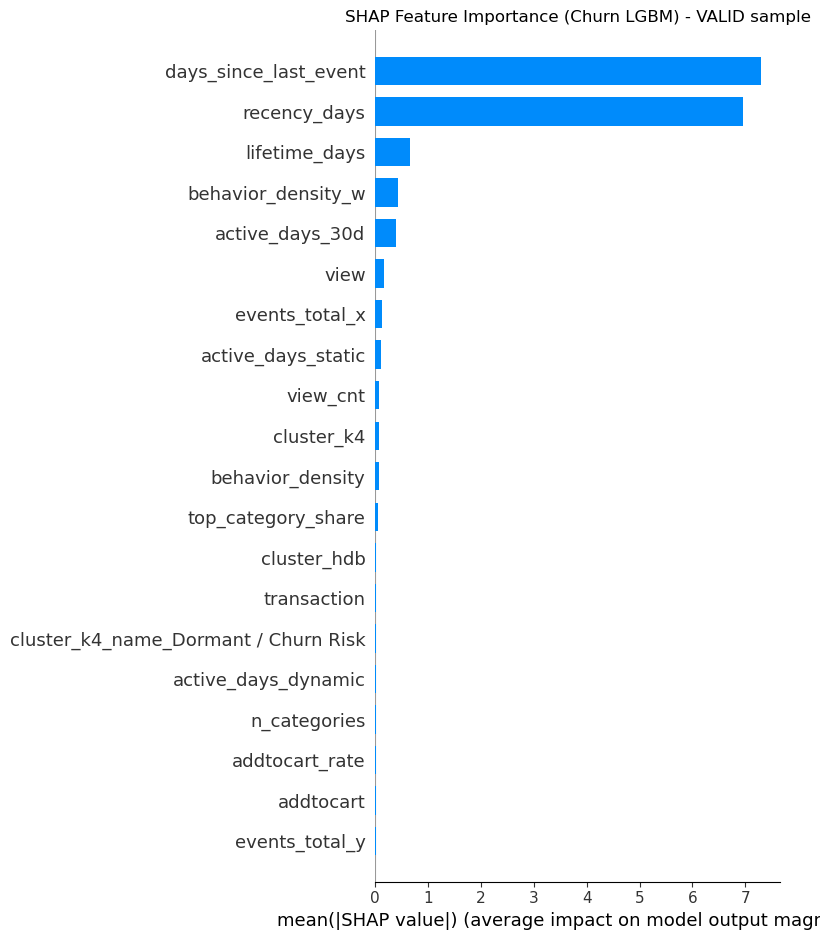

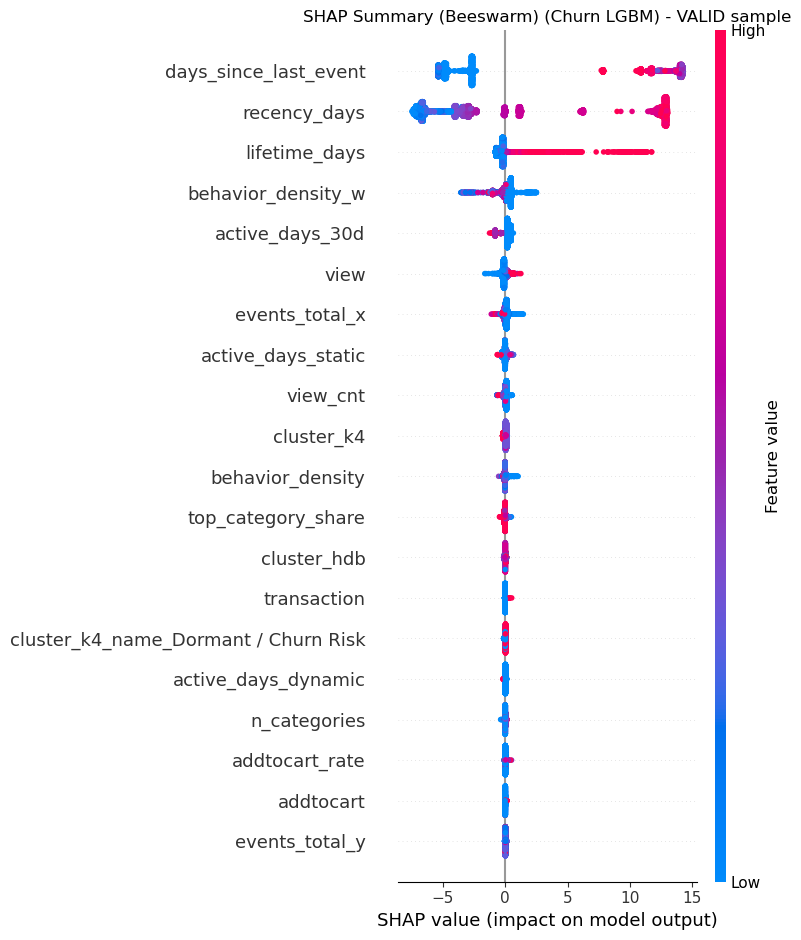

In [63]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt

# -----------------------------
# 0) SHAP import
# -----------------------------
try:
    import shap
except ImportError as e:
    raise ImportError(
        "未安装 shap。请先在当前环境运行：pip install shap\n"
        "然后重新执行本 cell。"
    ) from e

EPS = 1e-9
RANDOM_SEED = 42
T_CHURN_NEW = 14
TARGET = f"label_churn_{T_CHURN_NEW}"
N_SHAP = 5000  # <- 可改：2000/5000/10000

def build_one_row_per_user(df):
    df = df.copy().replace([np.inf, -np.inf], np.nan)
    rng = np.random.default_rng(RANDOM_SEED)
    df["_rand"] = rng.random(len(df))
    df_one = (df.sort_values(["user_id", "_rand"])
                .groupby("user_id", as_index=False)
                .head(1)
                .drop(columns=["_rand"])
                .reset_index(drop=True))
    return df_one

def temporal_split(df_one):
    anchors_sorted = np.array(sorted(df_one["anchor_date"].unique()))
    nA = len(anchors_sorted)

    a_train = anchors_sorted[: int(nA * 0.70)]
    a_valid = anchors_sorted[int(nA * 0.70): int(nA * 0.85)]
    a_test  = anchors_sorted[int(nA * 0.85):]

    if len(a_valid) == 0: a_valid = anchors_sorted[-2:-1]
    if len(a_test)  == 0: a_test  = anchors_sorted[-1:]

    train = df_one[df_one["anchor_date"].isin(a_train)]
    valid = df_one[df_one["anchor_date"].isin(a_valid)]
    test  = df_one[df_one["anchor_date"].isin(a_test)]
    return train, valid, test

def get_feature_names_from_preprocessor(preprocessor: ColumnTransformer):
    names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == "remainder" and trans == "drop":
            continue
        if hasattr(trans, "get_feature_names_out"):
            try:
                fn = trans.get_feature_names_out(cols)
                names.extend(fn.tolist())
            except Exception:
                fn = trans.get_feature_names_out()
                names.extend(fn.tolist())
        else:
            if isinstance(cols, (list, tuple, np.ndarray)):
                names.extend([str(c) for c in cols])
            else:
                names.append(str(cols))
    return np.array(names, dtype=object)

# -----------------------------
# 1) 数据：one-row-per-user + split
# -----------------------------
df_one = build_one_row_per_user(data_churn)
train, valid, test = temporal_split(df_one)

print("Rows train/valid/test:", train.shape, valid.shape, test.shape)
print("Positive rate (train/valid/test):",
      train[TARGET].mean(), valid[TARGET].mean(), test[TARGET].mean())

# -----------------------------
# 2) FULL features（不做 ablation）
# -----------------------------
drop_cols = {"user_id", "anchor_date", "label_conversion", "label_churn", TARGET}
feature_cols = [c for c in df_one.columns if c not in drop_cols]

cat_cols = [c for c in feature_cols if str(df_one[c].dtype) in ["object", "category"]]
num_cols = [c for c in feature_cols if c not in cat_cols]

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

pos = train[TARGET].sum()
neg = len(train) - pos
spw = (neg / (pos + EPS)) if pos > 0 else 1.0

clf = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=200,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=spw,
    force_row_wise=True,
    verbose=-1
)

model = Pipeline([("pre", pre), ("clf", clf)])
model.fit(train[feature_cols], train[TARGET])

# -----------------------------
# 3) 取 VALID 做 SHAP（抽样）
# -----------------------------
valid_s = valid.sample(n=min(N_SHAP, len(valid)), random_state=RANDOM_SEED).copy()

X_valid_tr = model.named_steps["pre"].transform(valid_s[feature_cols])
feat_names = get_feature_names_from_preprocessor(model.named_steps["pre"])

print("Transformed feature dim:", X_valid_tr.shape[1], "| names:", len(feat_names))

# -----------------------------
# 4) SHAP 计算（TreeExplainer）
# -----------------------------
explainer = shap.TreeExplainer(model.named_steps["clf"])
shap_values = explainer.shap_values(X_valid_tr)

# 二分类：有的版本返回 list([class0, class1])，有的直接返回 ndarray
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

# -----------------------------
# 5) Plot：summary bar + beeswarm
# -----------------------------
# bar：全局重要性（mean(|SHAP|)）
plt.figure(figsize = (6, 14))
shap.summary_plot(shap_vals, X_valid_tr, feature_names=feat_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Churn LGBM) - VALID sample") 
plt.tight_layout()
plt.show()

# beeswarm：方向与分布
plt.figure(figsize = (6, 14))
shap.summary_plot(shap_vals, X_valid_tr, feature_names=feat_names, show=False)
plt.title("SHAP Summary (Beeswarm) (Churn LGBM) - VALID sample")
plt.tight_layout()
plt.show()